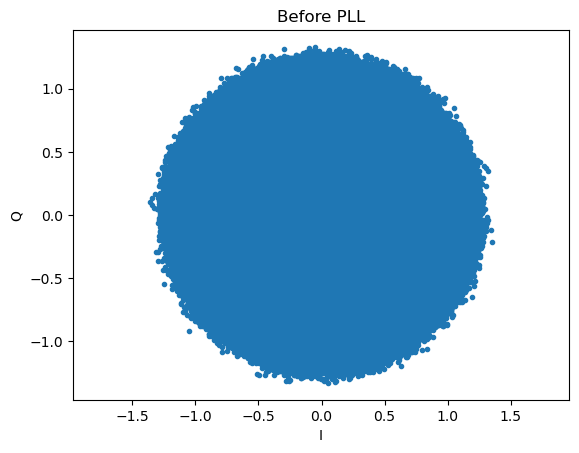

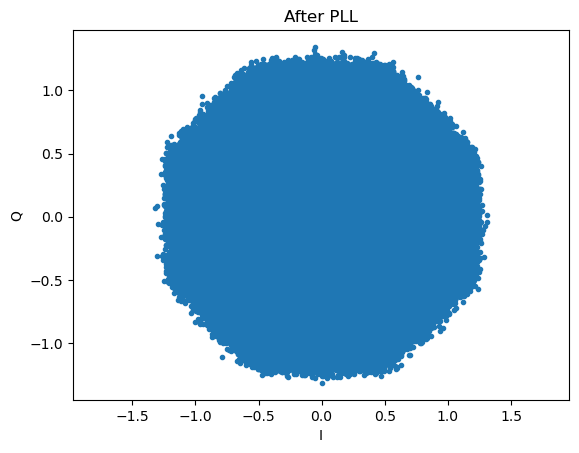

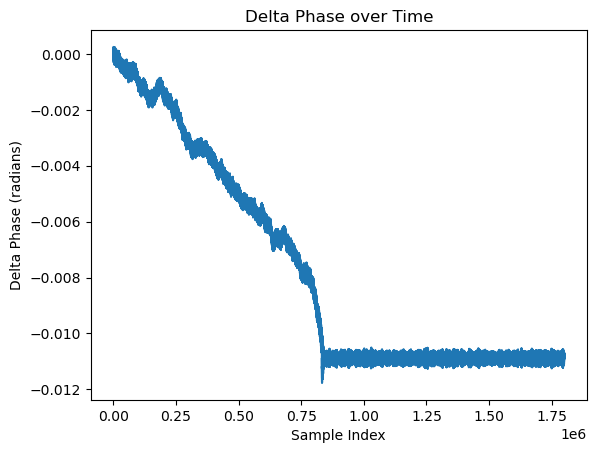

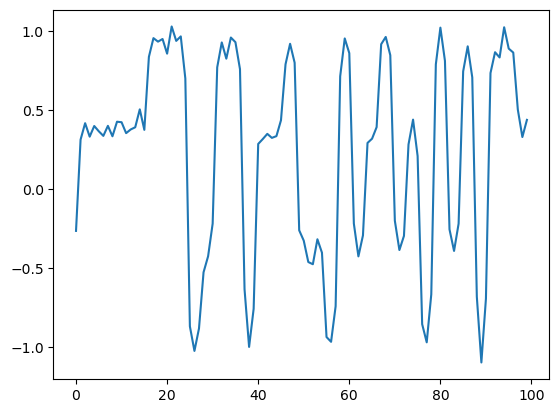

[(0.5174167270766916+1.0114528851574844j), (-0.43163492731526765-0.9939970784289828j), (0.9811870288810804+0.3678902466780166j), (-0.42000840506227577-0.9882952600778477j), (-1.0059586500595932+0.46576853855177247j), (0.41051219946053397-0.9940273639241268j), (0.43765794886945986+0.8908037231300846j), (-0.40594888114047933+0.978347131728303j), (-0.5206580765768949-0.9200239038886469j), (-1.0057861654970577+0.5139537566969266j), (0.3899978955649537-0.9668306632667484j), (0.40955430937472775-0.8807268132272554j), (0.3840855694029695-0.9168862966771383j), (0.36153594390618665-1.0247658544310696j), (0.39530555264188666-0.9169856933987935j), (1.0372891625988196+0.44466517887383405j), (0.3116127578117878-1.0178661328412733j), (0.9412059901651258-0.4394051002635675j), (-0.4563539922090495-0.8697925418828419j), (0.4414409524969072+0.9136228385276699j), (-0.9439222186832827-0.33321009466754636j), (-0.9360950536645861-0.3805431010835826j), (-0.35253997733510944-0.9655832156733659j), (-0.91891660

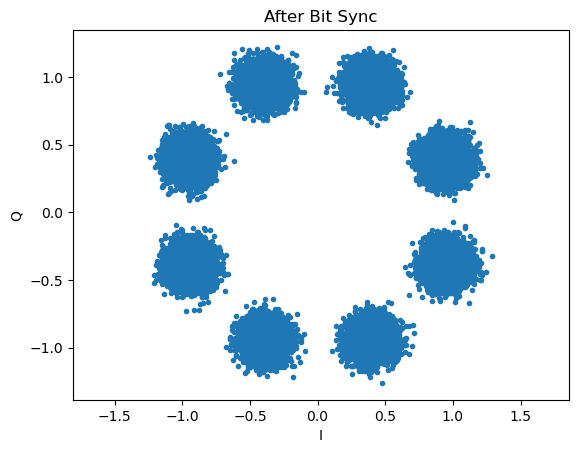

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.signal as signal
from scipy import interpolate


freq_baseband = 10_000_000  # 10 MHz
freq_delta_carrier = 52_000  # 100 kHz
# freq_delta_carrier = 0

freq_sampling_tx = 30_000_000  # 30 MHz
freq_sampling_rx = 30_000_000 - 1000


num_samples_tx = 30_000 * 5 * 4
num_samples_rx = int(num_samples_tx * freq_sampling_rx / freq_sampling_tx)
# num_samples = 30

mpsk = 8 
samples_per_bit = 3

# Generate random baseband signal
baseband_signal = np.array([random.randint(0, mpsk - 1) for _ in range(num_samples_tx)])
# baseband_signal = np.array([0, 2]* (num_samples_tx // 2))  # Example: alternating 0 and 2 for simplicity
    



# sampled tx signal
t = np.arange(num_samples_tx * samples_per_bit) / freq_sampling_tx
# repeated_baseband = baseband_signal[np.floor(t * freq_baseband).astype(int) % num_samples_tx]
repeated_baseband = np.repeat(baseband_signal, samples_per_bit)

tx_signal = np.exp(1j * 2 * np.pi * repeated_baseband / mpsk) * np.exp(1j * 2 * np.pi * freq_delta_carrier * t)




# 调幅
# amp_mask = np.array([random.randint(1, 2) for _ in range(num_samples_tx * samples_per_bit)])
# amp_mask = (amp_mask - 0.5 ) * 2
# tx_signal = tx_signal * amp_mask




# rx_signal = tx_signal
rx_signal = signal.resample(tx_signal, num_samples_rx * samples_per_bit, window=("kaiser", 2.0))
# 插值取点
# rx_signal = np.interp(np.arange(num_samples_rx * 3), np.linspace(0, num_samples_tx * 3, num_samples_tx * 3), tx_signal)

# tx_interpolated = interpolate.interp1d(np.arange(num_samples_tx * 3), tx_signal, kind='cubic')
# rx_signal = tx_interpolated(np.linspace(0, num_samples_tx - 1, num_samples_rx))
# # 低通
# response = [0.2, 1, 0.2]
# response = np.array(response) / np.sum(response)
# rx_signal = signal.convolve(rx_signal, response, mode="same")

# Add noise
rx_signal += (np.random.randn(len(rx_signal)) + 1j * np.random.randn(len(rx_signal))) * 0.05

def plot_star(signal, title="Star Diagram"):
    plt.Figure(figsize=(6, 6))
    plt.plot(np.real(signal), np.imag(signal), ".")
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.axis("equal")
    plt.title(title)
    plt.show()


class Delay:
    def __init__(self, delay):
        self.delay = delay
        self.buffer = np.zeros(delay)

    def step(self, sample):
        out_sample = self.buffer[0]
        self.buffer = np.roll(self.buffer, -1)
        self.buffer[-1] = sample
        return out_sample


class PID:
    def __init__(self, Kp, Ki, Kd):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.prev_error = 0
        self.integral = 0

    def step(self, error):
        self.integral += error
        derivative = error - self.prev_error
        self.prev_error = error
        return self.Kp * error + self.Ki * self.integral + self.Kd * derivative


class DDS:
    def __init__(self, phase_max, base_omega=0):
        self.phase_max = phase_max
        self.phase = 0
        self.base_omega = base_omega

    def get_value(self):
        return np.exp(1j * self.phase)

    def step(self, delta_phase):
        self.phase += (self.base_omega + delta_phase) % self.phase_max
        
        # delta_phase += self.base_omega

        # over_flow = False
        # over_flow_half = False
        # frac_delay = 0

        # new_phase = self.phase + delta_phase
        # if (new_phase >= self.phase_max / 2) and (self.phase < self.phase_max / 2):
        #     over_flow_half = True
        #     frac_delay = new_phase - self.phase_max / 2

        # self.phase = new_phase
        # if self.phase >= self.phase_max:
        #     self.phase -= self.phase_max
        #     over_flow = True
        #     frac_delay = self.phase

        # if delta_phase != 0:
        #     frac_delay = 1 - frac_delay / delta_phase

        # return over_flow, over_flow_half, frac_delay


class CordicError:
    def __init__(self, phase_max):
        self.phase_max = phase_max
        self.mpsk = mpsk
        self.delay = Delay(delay=3)

    def step(self, data):
        # + np.pi / self.mpsk
        error = -(np.angle(data)) % (2 * np.pi / self.mpsk) - np.pi / self.mpsk
        return self.delay.step(error)


class Cordic:
    def __init__(self, pid: PID, dds: DDS):
        self.pid = pid
        self.dds = dds
        self.error_detector = CordicError(phase_max=2 * np.pi)
        self.delta_phase_logger = []

    def step(self, sample):
        dds_value = self.dds.get_value()
        out_sample = dds_value * sample
        error = self.error_detector.step(out_sample)
        delta_phase = self.pid.step(error)
        self.dds.step(delta_phase)
        self.delta_phase_logger.append(delta_phase)
        return out_sample



cordic = Cordic(pid=PID(Kp=0.0005, Ki=0.00001, Kd=0), dds=DDS(phase_max=2 * np.pi))


plot_star(rx_signal, title="Before PLL")


class BitSync:
    def __init__(self, samples_per_bit):
        self.samples_per_bit = samples_per_bit
        self.phase_per_symbol = 2 * np.pi / mpsk
        self.counter = 0
        self.last_sample_place = 0

    def step(self, sample):
        # 检查相位
        phase = np.angle(sample)
        for i in range(mpsk):
            if phase <= (i + 1) * self.phase_per_symbol - np.pi:
                sample_place = i
                break
        if sample_place != self.last_sample_place:
            self.counter = (self.samples_per_bit + 1) // 2 - 1
        else:
            self.counter = (self.counter + 1) % self.samples_per_bit
        
        self.last_sample_place = sample_place
        if self.counter == (self.samples_per_bit + 1) // 2:
            return sample






# print(rx_signal[:30])
# rx_signal 每个值前插入up_sample_rate个0
# up_sample_rate = 6
# rx_signal = np.repeat(rx_signal, up_sample_rate)
# print(rx_signal[:30])
# rx_signal = signal.convolve(rx_signal, np.ones(up_sample_rate) / up_sample_rate, mode='same')

# print(rx_signal[:30])

rx_signal = np.array([cordic.step(sample) for sample in rx_signal])


plot_star(rx_signal[int(num_samples_tx * 0.9) :], title="After PLL")

plt.plot(cordic.delta_phase_logger)
plt.title("Delta Phase over Time")
plt.xlabel("Sample Index")
plt.ylabel("Delta Phase (radians)")
plt.show()


plt.plot(rx_signal.real[-100:], label="I")
plt.show()


bit_sync = BitSync(samples_per_bit=samples_per_bit)
# print(synced_samples)
synced_samples = [bit_sync.step(sample) for sample in rx_signal]
# print(synced_samples[-100:])
synced_samples = [s for s in synced_samples if s is not None]
print(synced_samples[-100:])

plot_star(synced_samples[int(len(synced_samples) * 0.9) :], title="After Bit Sync")

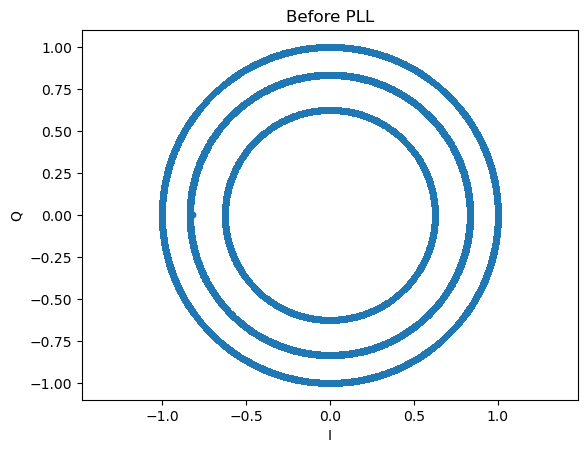

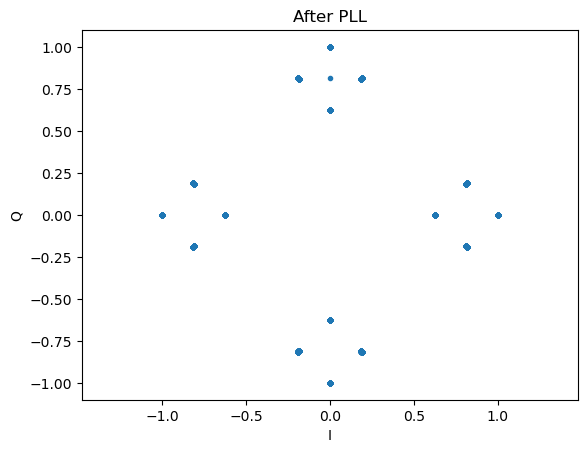

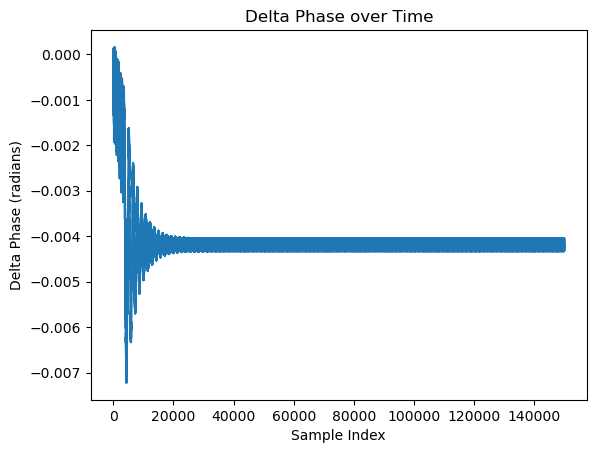

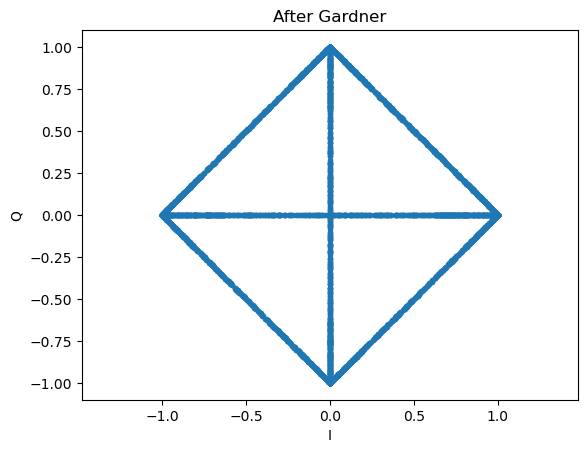

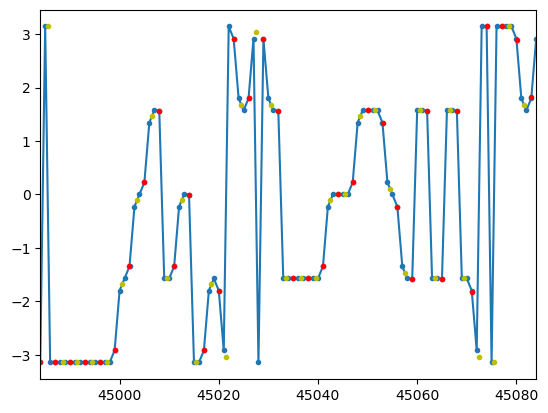

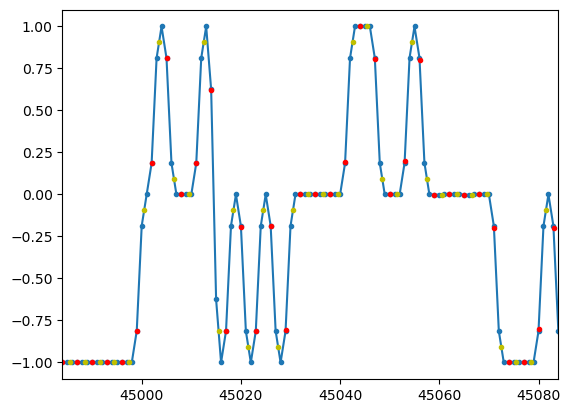

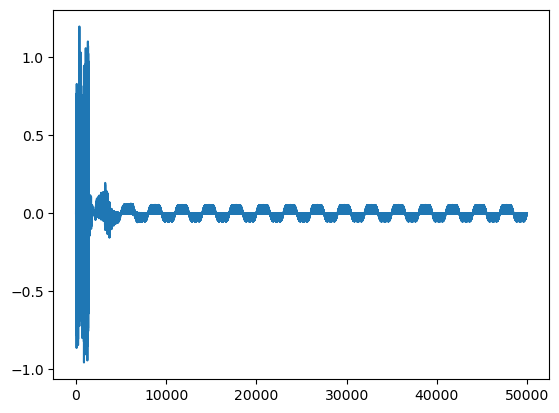

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import scipy.signal as signal
from scipy import interpolate


freq_baseband = 10_000_000  # 10 MHz
freq_delta_carrier = 20_000  # 100 kHz
# freq_delta_carrier = 0

freq_sampling_tx = 30_000_000  # 30 MHz
freq_sampling_rx = 30_000_000 - 10000


num_samples_tx = 50_000
num_samples_rx = int(num_samples_tx * freq_sampling_rx / freq_sampling_tx)
# num_samples = 30

mpsk = 4

# Generate random baseband signal
baseband_signal = np.array([random.randint(0, mpsk - 1) for _ in range(num_samples_tx)])
# baseband_signal = np.array([0, 2]* (num_samples_tx // 2))  # Example: alternating 0 and 2 for simplicity
    
# sampled tx signal
t = np.arange(num_samples_tx * 3) / freq_sampling_tx
# repeated_baseband = baseband_signal[np.floor(t * freq_baseband).astype(int) % num_samples_tx]
repeated_baseband = np.repeat(baseband_signal, 3)

tx_signal = np.exp(1j * 2 * np.pi * repeated_baseband / mpsk) * np.exp(1j * 2 * np.pi * freq_delta_carrier * t)
rx_signal = tx_signal
# rx_signal = signal.resample(tx_signal, num_samples_rx, window=("kaiser", 6.0))
# 插值取点
# rx_signal = np.interp(np.arange(num_samples_rx), np.linspace(0, num_samples_tx, num_samples_tx), tx_signal)
# tx_interpolated = interpolate.interp1d(np.arange(num_samples_tx), tx_signal, kind='linear', fill_value="extrapolate")
# rx_signal = tx_interpolated(np.linspace(0, num_samples_tx - 1, num_samples_rx))
# 低通
response = [0.3, 1, 0.3]
response = np.array(response) / np.sum(response)
rx_signal = signal.convolve(rx_signal, response, mode="same")

# Add noise
# rx_signal += (np.random.randn(len(rx_signal)) + 1j * np.random.randn(len(rx_signal))) * 0.1

def plot_star(signal, title="Star Diagram"):
    plt.Figure(figsize=(6, 6))
    plt.plot(np.real(signal), np.imag(signal), ".")
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.axis("equal")
    plt.title(title)
    plt.show()


class Delay:
    def __init__(self, delay):
        self.delay = delay
        self.buffer = np.zeros(delay)

    def step(self, sample):
        out_sample = self.buffer[0]
        self.buffer = np.roll(self.buffer, -1)
        self.buffer[-1] = sample
        return out_sample

class PID:
    def __init__(self, Kp, Ki, Kd):
        self.Kp = Kp
        self.Ki = Ki
        self.Kd = Kd
        self.prev_error = 0
        self.integral = 0

    def step(self, error):
        self.integral += error
        derivative = error - self.prev_error
        self.prev_error = error
        return self.Kp * error + self.Ki * self.integral + self.Kd * derivative


class DDS:
    def __init__(self, phase_max, base_omega=0):
        self.phase_max = phase_max
        self.phase = 0
        self.base_omega = base_omega

    def get_value(self):
        return np.exp(1j * self.phase)

    def step(self, delta_phase):
        delta_phase += self.base_omega

        over_flow = False
        over_flow_half = False
        frac_delay = 0

        new_phase = self.phase + delta_phase
        if (new_phase >= self.phase_max / 2) and (self.phase < self.phase_max / 2):
            over_flow_half = True
            frac_delay = new_phase - self.phase_max / 2

        self.phase = new_phase
        if self.phase >= self.phase_max:
            self.phase -= self.phase_max
            over_flow = True
            frac_delay = self.phase

        if delta_phase != 0:
            frac_delay = 1 - frac_delay / delta_phase

        return over_flow, over_flow_half, frac_delay


class CordicError:
    def __init__(self, phase_max):
        self.phase_max = phase_max
        self.mpsk = mpsk
        self.delay = Delay(delay=3)

    def step(self, data):
        error = -(np.angle(data) + np.pi / self.mpsk) % (2 * np.pi / self.mpsk) - np.pi / self.mpsk
        return self.delay.step(error)


# class DataLogger:
#     def __init__(self, data_names):
#         self.data_names = data_names
#         self.data = []

#     def step(self, sample):
#         self.data.append({name: getattr(sample, name) for name in self.data_names})


class Cordic:
    def __init__(self, pid: PID, dds: DDS):
        self.pid = pid
        self.dds = dds
        self.error_detector = CordicError(phase_max=2 * np.pi)
        self.delta_phase_logger = []

    def step(self, sample):
        dds_value = self.dds.get_value()
        out_sample = dds_value * sample
        error = self.error_detector.step(out_sample)
        delta_phase = self.pid.step(error)
        self.dds.step(delta_phase)
        self.delta_phase_logger.append(delta_phase)
        return out_sample


class FarrowFilter3:
    def __init__(self):
        self.coeffs = [[0, 6, 0, 0], [-2, -3, 6, -1], [3, -6, 3, 0], [-1, 3, -3, 1]]
        self.coeffs = np.array(self.coeffs) / 6.0
        self.buffer = np.zeros(4, dtype=np.complex64)  # +3 for cubic interpolation

    def step(self, sample):
        self.buffer = np.roll(self.buffer, -1)
        self.buffer[-1] = sample

    def interpolate(self, mu):
        # print(mu)
        # print(self.buffer)
        v = np.array([np.sum(self.buffer * self.coeffs[i]) for i in range(4)])
        out = ((v[3] * mu + v[2]) * mu + v[1]) * mu + v[0]
        # print(out)
        return out
    
class FarrowFilter1:
    def __init__(self):
        self.buffer = np.zeros(2, dtype=np.complex64)

    def step(self, sample):
        self.buffer = np.roll(self.buffer, -1)
        self.buffer[-1] = sample

    def interpolate(self, mu):
        out = self.buffer[-1] * mu + self.buffer[-2] * (1 - mu)
        return out


# class FarrowFilter2:
#     def __init__(self):
#         self.coeffs = [[0, 1, 0, 0], [1, -1, -1, 1], [-1, 1, 1, -1]]
#         self.coeffs = np.array(self.coeffs)
#         self.coeffs[1:] = self.coeffs[1:] / 2.0
#         self.buffer = np.zeros(4, dtype=np.complex64)  # +3 for cubic interpolation

#     def step(self, sample):
#         self.buffer = np.roll(self.buffer, -1)
#         self.buffer[-1] = sample

#     def interpolate(self, mu):
#         # print(self.buffer)
#         v = np.array([np.sum(self.buffer * self.coeffs[i]) for i in range(4)])
#         out = (v[2] * mu + v[1]) * mu + v[0]
#         return out


class GardnerError:
    def __init__(self, phase_max):
        self.phase_max = phase_max
        self.mpsk = mpsk
        self.prev_sample = 0
        self.prev_mid_sample = 0

    def get_relative_angle(self, sample):
        return -(np.angle(sample) + np.pi / self.mpsk) % (self.phase_max / self.mpsk) - self.phase_max / 2 / self.mpsk

    def set_mid_sample(self, mid_sample):
        self.prev_mid_sample = self.get_relative_angle(mid_sample)

    def step(self, sample):
        sample = self.get_relative_angle(sample)
        error = self.prev_mid_sample * (sample - self.prev_sample)
        self.prev_sample = sample
        return error


class Gardner:
    def __init__(self, pid: PID, phase_max):
        self.farrow = FarrowFilter1()
        self.pid = pid
        self.dds = DDS(phase_max, phase_max / 3.001)
        self.error_detector = GardnerError(phase_max)
        self.delta_phase = 0

        self.counter = 0
        self.place_log = []
        self.error_log = []
        self.point_log = []
        self.place_mid_log = []
        self.point_mid_log = []

    def step(self, sample):
        self.counter += 1
        self.farrow.step(sample)
        overflow, overflow_half, frac_delay = self.dds.step(self.delta_phase)
        point = self.farrow.interpolate(frac_delay)
        if overflow_half:
            self.error_detector.set_mid_sample(point)
            self.place_mid_log.append(self.counter + frac_delay - 2)
            self.point_mid_log.append(point)
        if overflow:
            error = self.error_detector.step(point)
            self.delta_phase = self.pid.step(error)
            self.place_log.append(self.counter + frac_delay - 2)
            self.error_log.append(error)
            self.point_log.append(point)
            return point


cordic = Cordic(pid=PID(Kp=0.0006, Ki=0.00002, Kd=0), dds=DDS(phase_max=2 * np.pi))


plot_star(rx_signal, title="Before PLL")

# print(rx_signal[:30])
# rx_signal 每个值前插入up_sample_rate个0
# up_sample_rate = 6
# rx_signal = np.repeat(rx_signal, up_sample_rate)
# print(rx_signal[:30])
# rx_signal = signal.convolve(rx_signal, np.ones(up_sample_rate) / up_sample_rate, mode='same')

# print(rx_signal[:30])

rx_signal = np.array([cordic.step(sample) for sample in rx_signal])


plot_star(rx_signal[int(num_samples_tx * 0.9) :], title="After PLL")

plt.plot(cordic.delta_phase_logger)
plt.title("Delta Phase over Time")
plt.xlabel("Sample Index")
plt.ylabel("Delta Phase (radians)")
plt.show()


# plt.plot(np.angle(rx_signal)[-100:])
# plt.show()

rx_signal_before_gardner = rx_signal.copy()

gardner = Gardner(pid=PID(Kp=0.000001, Ki=0.0000001, Kd=0), phase_max=2 * np.pi)
rx_signal = np.array([gardner.step(sample) for sample in rx_signal])

# 打印非none的值的idx
# print(np.where(rx_signal != None))

# 去除none
rx_signal = rx_signal[rx_signal != None]

rx_signal = rx_signal.astype(np.complex64)


plot_star(gardner.point_log[int(len(gardner.point_log) * 0.9): ], title="After Gardner")

plt.plot(np.angle(rx_signal_before_gardner), ".-")
plt.plot(gardner.place_log, np.angle(gardner.point_log), ".", c="r")
plt.plot(gardner.place_mid_log, np.angle(gardner.point_mid_log), ".", c="y")
plt.xlim(int(len(rx_signal) * 0.9), int(len(rx_signal) * 0.9) + 100)
plt.show()

plt.plot(rx_signal_before_gardner, ".-")
plt.plot(gardner.place_log, gardner.point_log, ".", c="r")
plt.plot(gardner.place_mid_log, gardner.point_mid_log, ".", c="y")
plt.xlim(int(len(rx_signal) * 0.9), int(len(rx_signal) * 0.9) + 100)
plt.show()

plt.plot(gardner.error_log)


# rx_signal_upsampled = signal.resample(rx_signal, num_samples_rx * 6, window=('kaiser', 6.0))

# plt.plot(np.angle(rx_signal_upsampled)[-100:])

# rx_phase = np.angle(rx_signal)
# plt.plot(t, rx_phase)
# plt.show()

# # 星座图
# # squared axis
# plt.figure(figsize=(6, 6))
# plt.axis('equal')
# plt.scatter(np.real(rx_signal), np.imag(rx_signal))
# plt.xlabel('I')
# plt.ylabel('Q')
# plt.show()

In [ ]:
error_detector = GardnerError(phase_max=2 * np.pi)
error_detector.set_mid_sample(1j - 1)
error_detector.step(1j)
error_detector.step(1j + 1)

np.float64(0.0)

In [ ]:
dds = DDS(2 * np.pi, 2 * np.pi / 10)

for i in range(20):
    overflow, overflow_half, frac_delay = dds.step(2 * np.pi / 20)
    # print(overflow, overflow_half, (1-frac_delay)+i)
    if overflow:
        print(frac_delay + i)
    if overflow_half:
        print(frac_delay + i)

3.3333333333333335
6.666666666666667
10.0
13.333333333333334
16.666666666666668
20.0


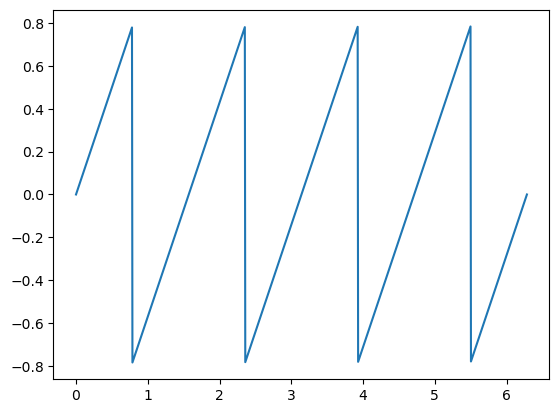

In [ ]:
mpsk = 4
phases = np.linspace(0, 2 * np.pi, 1000)
angles = (np.angle(np.exp(1j * phases)) + np.pi / mpsk) % (2 * np.pi / mpsk) - np.pi / mpsk
plt.plot(phases, angles)
plt.show()

# np.angle(-1j-10)

In [ ]:
delay = Delay(delay=3)
for i in range(10):
    print(delay.step(i + 12))

0.0
0.0
0.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0


In [ ]:
from scipy import signal

signal.conv

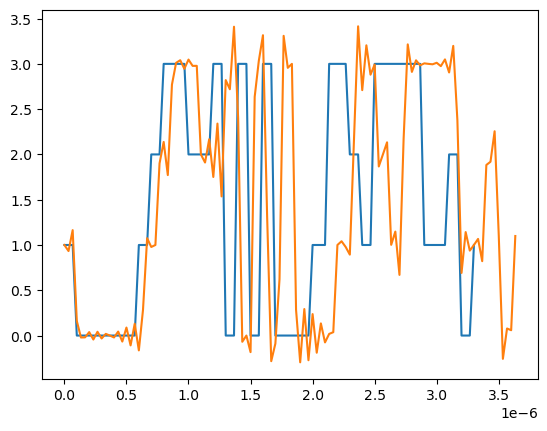

In [ ]:
num_samples = 100
freq_sampling = 100
t = np.arange(num_samples) / freq_sampling
sampled_baseband = baseband_signal[np.floor(t * freq_baseband).astype(int) % num_samples]
plt.plot(t, sampled_baseband)


# resampled
resampled_baseband = signal.resample(sampled_baseband, num_samples + 10)
plt.plot(np.arange(num_samples + 10) / freq_sampling, resampled_baseband)

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0


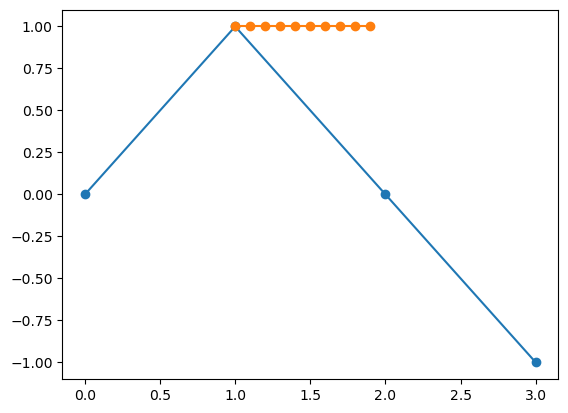

In [2]:
class FarrowFilter2:
    def __init__(self):
        self.coeffs = [[0, 1, 0, 0], [-1, -1, 3, -1], [1, -1, -1, 1]]
        self.coeffs = np.array(self.coeffs)
        self.coeffs[1:] = self.coeffs[1:] / 2.0
        self.buffer = np.zeros(4)  # +3 for cubic interpolation

    def step(self, sample):
        self.buffer = np.roll(self.buffer, -1)
        self.buffer[-1] = sample

    def interpolate(self, mu):
        v = np.array([np.sum(self.buffer * self.coeffs[i]) for i in range(3)])
        # v[1] += self.buffer[2]
        out = (v[2] * mu + v[1]) * mu + v[0]
        return out


# test = FarrowFilter3()
# for i in range(4):
#     test.step(i)

# for i in np.arange(0, 1, 0.1):
#     print(test.interpolate(i))

# x = np.sin(np.linspace(0, 2 * np.pi, 4))
x = [0, 1, 0, -1]
test = FarrowFilter2()
for i in range(4):
    test.step(x[i])

for i in np.arange(0, 1, 0.1):
    print(test.interpolate(i))

plt.plot(x, "o-")
plt.plot(np.arange(0 + 1, 1 + 1, 0.1), [test.interpolate(i) for i in np.arange(0, 1, 0.1)], "o-")

In [ ]:
10 % 3.5

3.0